Label shape: (9216, 5120, 3)


(-0.5, 5119.5, 9215.5, -0.5)

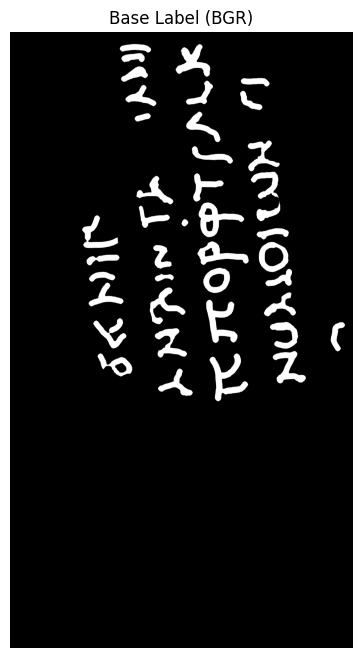

In [1]:
# Cell 1: Imports and load eroded inklabel image (segment 20230827161847) as BGR
import os, json, math, random
import cv2
import numpy as np
import matplotlib.pyplot as plt

SEGMENT_ID = 20230827161847
TILE_SIZE = 32  # must match config

label_path = f"./eroded_inklabels/{SEGMENT_ID}.png"
if not os.path.exists(label_path):
    raise FileNotFoundError(f"Label file not found: {label_path}")

label_gray = cv2.imread(label_path, cv2.IMREAD_GRAYSCALE)
if label_gray is None:
    raise RuntimeError("Failed to load label image.")

# Convert to BGR (OpenCV default BGR)
label_bgr = cv2.cvtColor(label_gray, cv2.COLOR_GRAY2BGR)
print("Label shape:", label_bgr.shape)
plt.figure(figsize=(8,8)); plt.title("Base Label (BGR)"); plt.imshow(cv2.cvtColor(label_bgr, cv2.COLOR_BGR2RGB)); plt.axis('off')

In [3]:
# Cell 2: Read hard mining JSONL file
# Configure these: point to the run directory and epoch whose mining file you want to inspect.
jsonl_path = "hard_mining_epoch_4.jsonl"

hard_negatives = []  # label=0 scored high
hard_positives = []  # label=1 scored low
meta = {}

print("Reading:", jsonl_path)
if not os.path.exists(jsonl_path):
    raise FileNotFoundError(f"Mining file not found: {jsonl_path}")

with open(jsonl_path, 'r') as f:
    for line in f:
        line=line.strip()
        if not line:
            continue
        try:
            obj = json.loads(line)
        except json.JSONDecodeError:
            continue
        if obj.get('_type') == 'meta':
            meta = obj
            continue
        lbl = obj.get('label')
        if lbl == 0:
            hard_negatives.append(obj)
        elif lbl == 1:
            hard_positives.append(obj)

print(f"Loaded {len(hard_negatives)} hard negatives, {len(hard_positives)} hard positives")
if meta:
    print("Meta counts:", meta)
hard_negatives[:3], hard_positives[:3]

Reading: hard_mining_epoch_4.jsonl
Loaded 1926 hard negatives, 2824 hard positives
Meta counts: {'_type': 'meta', 'hard_negatives': 1926, 'hard_positives': 2824}


([{'z': 28, 'y': 200, 'x': 1000, 'score': 0.7291123270988464, 'label': 0},
  {'z': 28, 'y': 200, 'x': 1288, 'score': 0.704970121383667, 'label': 0},
  {'z': 28, 'y': 232, 'x': 1192, 'score': 0.6826396584510803, 'label': 0}],
 [{'z': 28, 'y': 200, 'x': 1672, 'score': 0.35797038674354553, 'label': 1},
  {'z': 28, 'y': 200, 'x': 1736, 'score': 0.3570077419281006, 'label': 1},
  {'z': 28, 'y': 200, 'x': 1768, 'score': 0.3765065371990204, 'label': 1}])

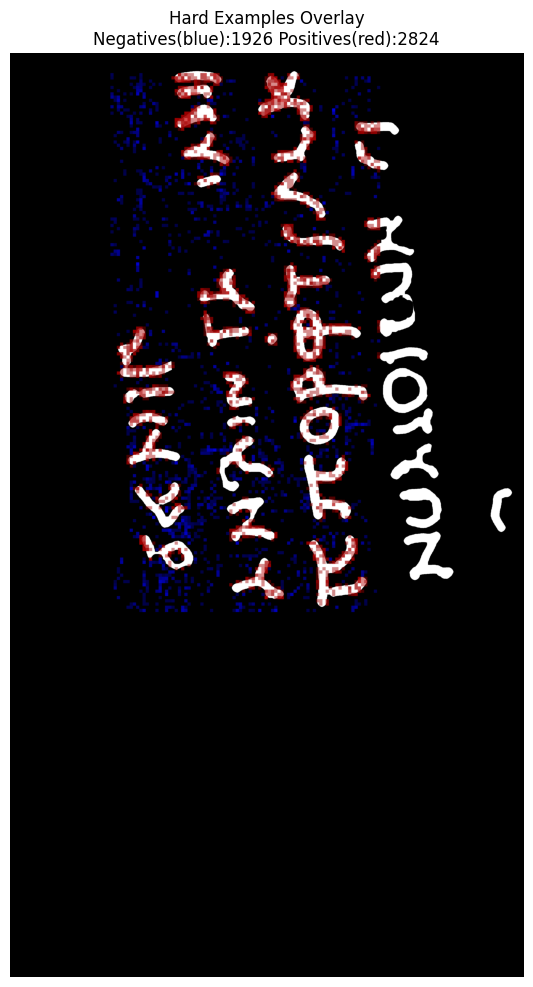

In [4]:
# Cell 3: Visualize tiles (Blue = hard negatives, Red = hard positives)
# Intensity mapping:
#  - Hard negatives: intensity = score (higher predicted prob => stronger blue)
#  - Hard positives: intensity = 1 - score (lower predicted prob => stronger red)

overlay = label_bgr.copy()

def draw_tile(img, x, y, color, alpha=0.4):
    h, w = img.shape[:2]
    x2 = min(x+TILE_SIZE, w)
    y2 = min(y+TILE_SIZE, h)
    # Blend solid color into region
    roi = img[y:y2, x:x2]
    color_arr = np.zeros_like(roi)
    color_arr[:] = color  # BGR
    cv2.addWeighted(color_arr, alpha, roi, 1-alpha, 0, dst=roi)

# Draw hard negatives (blue)
for rec in hard_negatives:
    x = rec['x']; y = rec['y']; s = float(rec['score'])
    intensity = max(0.0, min(1.0, s))
    b = int(255 * intensity)
    color = (b, 0, 0)  # Blue channel
    draw_tile(overlay, x, y, color, alpha=0.45)

# Draw hard positives (red)
for rec in hard_positives:
    x = rec['x']; y = rec['y']; s = float(rec['score'])
    intensity = max(0.0, min(1.0, 1.0 - s))
    r = int(255 * intensity)
    color = (0, 0, r)
    draw_tile(overlay, x, y, color, alpha=0.45)

plt.figure(figsize=(12,12))
plt.title(f"Hard Examples Overlay\nNegatives(blue):{len(hard_negatives)} Positives(red):{len(hard_positives)}")
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()